In [1]:
import numpy as np, matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib
import corner
import re
import pickle
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
import BaryonForge as bfg
import pyccl as ccl
from scipy.integrate import cumulative_trapezoid, simpson
from astropy import constants as con
import os
import emcee

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams.update(
    {
        'text.usetex': False,
        'font.family': 'stixgeneral',
        'mathtext.fontset': 'stix',
    }
)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['image.origin'] = 'lower'
sns.set_context('talk') 
sns.set(font_scale=2)
sns.set_palette('colorblind')
sns.set_style('ticks')
plt.rcParams['font.family'] = 'Times New Roman'

cmap = plt.get_cmap("rainbow")
colors = [cmap(i) for i in np.linspace(0, 1, 10)]

os.environ["PK_MODEL"] = "BCEmu7_high_z"
os.environ["METHOD"] = "exact"
os.environ["N_FRB"]    = "100"
os.environ["N_PARAMS"] = "1"
from mcmc_funcs import *

from astropy.cosmology import Planck18 as cosmo

cosmo_ccl = ccl.Cosmology(Omega_c = cosmo.Om0-cosmo.Ob0, 
                          Omega_b = cosmo.Ob0, 
                          h = cosmo.H0.value/100, 
                          sigma8 = 0.8111, 
                          n_s = 0.9665, 
                          matter_power_spectrum='linear'
                         )

import matplotlib as mpl

mpl.rcParams['axes.linewidth'] = 2
mpl.rcParams['xtick.major.width'] = 2
mpl.rcParams['ytick.major.width'] = 2
mpl.rcParams['xtick.minor.width'] = 1
mpl.rcParams['ytick.minor.width'] = 1

mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['ytick.major.size'] = 10
mpl.rcParams['xtick.minor.size'] = 5
mpl.rcParams['ytick.minor.size'] = 5


Not using emulators.
Unknown Pk_model!


## DES + WISE/Spitzer + SPT Clusters data

In [2]:
spt_cluster_redshifts = pd.read_csv("data/shm_relation/spt_cluster_redshifts.dat", sep="\t", comment="(", skiprows=[1])
spt_clusters = pd.read_csv("data/shm_relation/spt_clusters.dat", sep="\t", comment="(", skiprows=[1])

def split_pm(value):
    if isinstance(value, str):
        value = value.strip()
        if value in ["–", "-", "", "nan"]:
            return np.nan, np.nan
        match = re.match(r"([+-]?\d*\.?\d+)\s*[±]\s*([+-]?\d*\.?\d+)", value)
        if match:
            return float(match.group(1)), float(match.group(2))
        try:
            return float(value), np.nan
        except ValueError:
            return np.nan, np.nan
    return value, np.nan

cols_to_split = [c for c in spt_clusters.columns if c not in ["Name"]]

for col in cols_to_split:
    vals, errs = zip(*spt_clusters[col].map(split_pm))
    spt_clusters[col] = vals
    spt_clusters[col + "_err"] = errs

spt_clusters = spt_clusters.merge(spt_cluster_redshifts, on='Name', how='inner')

from colossus.halo import mass_defs
from colossus.cosmology import cosmology
cosmology.setCosmology('planck18')

spt_clusters['M200'] = np.array([mass_defs.changeMassDefinition((10**14)*spt_clusters['M500'][i], 1, spt_clusters['z'][i], '500c', '200c')[0] for i in range(len(spt_clusters))])
spt_clusters['M200_err'] = np.array([mass_defs.changeMassDefinition((10**14)*(spt_clusters['M500'][i]+spt_clusters['M500_err'][i]), 1, spt_clusters['z'][i], '500c', '200c')[0] for i in range(len(spt_clusters))])-spt_clusters['M200']
spt_clusters['M⋆'] = spt_clusters['M⋆']*1e12; spt_clusters['M⋆_err'] = spt_clusters['M⋆_err']*1e12
spt_clusters['M500'] = spt_clusters['M500']*1e14; spt_clusters['M500_err'] = spt_clusters['M500_err']*1e14

spt_clusters['Mstar_M500'] = spt_clusters['M⋆'] / spt_clusters['M500']
spt_clusters['Mstar_M500_err'] = spt_clusters['Mstar_M500'] * np.sqrt(
    (spt_clusters['M⋆_err'] / spt_clusters['M⋆'])**2 + (spt_clusters['Mstar_M500'] / spt_clusters['M500'])**2
)



In [3]:
bins = np.linspace(spt_clusters['M500'].min(), spt_clusters['M500'].max(), 4)
spt_clusters['bin'] = pd.cut(spt_clusters['M500'], bins=bins, labels=False, include_lowest=True)

binned_spt_clusters = (
    spt_clusters.groupby('bin')
      .apply(lambda g: pd.Series({
          'M500_min': g['M500'].min(),
          'M500_max': g['M500'].max(),

          # M*/M500 weighted stats
          'mean_Mstar_M500': np.mean(np.array([np.random.normal(g['Mstar_M500'], g['Mstar_M500_err']) for i in range(1000)]).flatten()),
          'err_Mstar_M500': np.std(np.array([np.random.normal(g['Mstar_M500'], g['Mstar_M500_err']) for i in range(1000)]).flatten()),

          # M500 weighted stats
          'mean_M500': np.mean(np.array([np.random.normal(g['M500'], g['M500_err']) for i in range(1000)]).flatten()),
          'err_M500': np.std(np.array([np.random.normal(g['M500'], g['M500_err']) for i in range(1000)]).flatten()),

          'N': len(g)
      }))
)

binned_spt_clusters.reset_index(drop=True, inplace=True)
binned_spt_clusters



,M500_min,M500_max,mean_Mstar_M500,err_Mstar_M500,mean_M500,err_M500,N
0,2.630000e+14,5.970000e+14,0.009602,0.003243,4.491200e+14,9.189057e+13,69.0
1,6.230000e+14,9.460000e+14,0.008091,0.002730,7.263067e+14,1.356143e+14,11.0
2,9.600000e+14,1.305000e+15,0.007701,0.001212,1.132186e+15,1.939111e+14,3.0


# f_star(M500) computed by integrating Baryonforge Profiles

In [4]:
def get_samples(mcmc_file):
    class RenameUnpickler(pickle.Unpickler):
        def find_class(self, module, name):
            if module.startswith("numpy._core"):
                module = module.replace("numpy._core", "numpy.core")
            return super().find_class(module, name)
    with open(mcmc_file, "rb") as f:
        results = RenameUnpickler(f).load()
    chain = results["chain"]
    samples = chain.reshape(-1, chain.shape[-1])
    # DMhost transformations
    DMhost_mean = np.exp(samples[:, -2] + ((samples[:, -1]**2)/2))
    DMhost_var = np.sqrt((np.exp(samples[:, -1]**2) - 1) * np.exp((2*samples[:, -2]) + (samples[:, -1]**2)))
    samples[:, -2] = DMhost_mean; samples[:, -1] = DMhost_var
    return samples


In [5]:
offset_Chabrier_to_Salpeter = +0.24
offset_Chabrier_to_Kroupa = +0.05
    

In [6]:
def get_rho_Mstar(H0_arr, Ob0_arr, Om0_arr, s8_arr, feedback_params_list, Pk_model, z, mode = HMcode_mode):
    def get_rho_Mstar_element(H0, Ob0, Om0, s8, feedback_params, Pk_model, z, HMcode_mode):
        a = 1/(1+z)
        h = H0/(100*1e5/Mpc)
        cosmo = ccl.Cosmology(Omega_c = Om0-Ob0, Omega_b = Ob0, h = H0/(100*1e5/Mpc), 
                              sigma8 = s8, n_s = 0.9665, matter_power_spectrum='linear')
        def stellar_profile_integral(M, a):
            if Pk_model == "HMcode":
                par = bfg.Profiles.Mead20.Tagn2pars(feedback_params["Tagn"], mode = mode)
                STR = bfg.Profiles.Mead20.Stars(**par)+bfg.Profiles.Mead20.SatelliteStars(**par)
            elif "BCEmu" in Pk_model:
                par = dict(theta_ej = feedback_params["theta_ej"], theta_co = 0.1,
                        M_c = (10**feedback_params["log_Mc"])/h,
                        mu_beta = feedback_params["mu_beta"],
                        eta = feedback_params["eta"],
                        eta_delta = feedback_params["eta_delta"], tau = -1.5,
                        tau_delta = 0, A = feedback_params["A"], M1 = 2.5e11/h,
                        epsilon_h = 0.015, a = 0.3, n = 2, epsilon = 4, p = 0.3,
                        q = 0.707, gamma = feedback_params["gamma"],
                        delta = feedback_params["delta"])
                STR = bfg.Profiles.Schneider19.Stars(**par, r_min_int = 1e-8, r_max_int = 1e2, r_steps = 100)+bfg.Profiles.Schneider19.SatelliteStars(**par, r_min_int = 1e-8, r_max_int = 1e2, r_steps = 100)
            else:
                print("Unknown Pk model!") 
            R200c = ccl.halos.massdef.MassDef200c.get_radius(cosmo, M, a)/a
            R = np.geomspace(1e-5 * R200c.min(), 10*R200c.max(), 100)
            STR = STR.real(cosmo, M=M, r=R, a=a)
            return scipy.integrate.simpson(STR*4*np.pi*R**2, x=R)


        rho_matter  = ccl.rho_x(cosmo, a, 'matter', is_comoving = True)
        f_b = cosmo['Omega_b']/cosmo['Omega_m']
        rho_baryon = rho_matter*f_b
        HMC  = ccl.halos.halo_model.HMCalculator(mass_function = 'Tinker08', halo_bias = 'Tinker10', 
                                                 mass_def = ccl.halos.massdef.MassDef200c, 
                                                 log10M_min = 9, log10M_max = 16, nM = 100)
        rho_Mstar = []
        for this_a in np.atleast_1d(a):
            int_star = lambda M: stellar_profile_integral(M, this_a)
            mean_star = HMC.integrate_over_massfunc(int_star, cosmo, this_a)
            rho_Mstar.append(mean_star)
        return rho_Mstar, rho_baryon

    def run_one(idx):
        H0, Ob0, Om0, s8, feedback_params = H0_arr[idx], Ob0_arr[idx], Om0_arr[idx], s8_arr[idx], feedback_params_list[idx]
        return get_rho_Mstar_element(H0, Ob0, Om0, s8, feedback_params, Pk_model, z, HMcode_mode)

    output = Parallel(n_jobs=9)(delayed(run_one)(i) for i in tqdm(range(len(H0_arr))))
    rho_Mstar_arr, rho_baryon_arr = np.array(output)[:, 0, :], np.array(output)[:, 1, :]
    return rho_Mstar_arr, rho_baryon_arr


def get_f_diffuse_f_star(H0_arr, Ob0_arr, Om0_arr, s8_arr, feedback_params_list, Pk_model, z, mode = HMcode_mode):
    rho_Mstar_arr, rho_baryons_arr = get_rho_Mstar(H0_arr, Ob0_arr, Om0_arr, s8_arr, feedback_params_list, Pk_model, z, HMcode_mode)
    rho_H2 = get_rho_H2(z)
    rho_HI = rho_H2/get_rho_H2_rho_HI(z)
    f_d_arr = 1 - ((rho_Mstar_arr+rho_H2[None, :]+rho_HI[None, :])/rho_baryons_arr)
    f_star_arr = rho_Mstar_arr/rho_baryons_arr
    return f_d_arr, f_star_arr



### DESI+SPT dataset: Varying $A$ and $\eta$ during inference


In [7]:
from getdist import MCSamples, plots

settineregs = {'ignore_rows':0, 'smooth_scale_1D':0.5, 'smooth_scale_2D':0.99}
new_col0 = np.random.uniform(0, 0.1, 10000)[:, None]
new_col1 = np.random.uniform(0.01, 0.5, 10000)[:, None]
samples = np.hstack([new_col0, new_col1])

settings = {'ignore_rows':0, 'smooth_scale_1D':0.5, 'smooth_scale_2D':0.99}

prior_chain = MCSamples(samples=samples, 
                        names=["A", "\eta"],
                        labels=["A", "\eta"],
                        settings=settings, label="Prior", 
                        ranges = {r"A": [0, 0.1], 
                                  r"\eta": [0.01, 0.5]
                                  })

BCEmu6_samples_spt_ChabrierIMF = get_samples("data/frb_results/emcee_BCEmu5_extended_SPTprior.pkl")
BCEmu6_samples_spt_KroupaIMF = get_samples("data/frb_results/shm_relation/emcee_BCEmu6_extended_SPTprior_KroupaIMF_perturbAonly.pkl")
BCEmu6_samples_spt_SalpeterIMF = get_samples("data/frb_results/shm_relation/emcee_BCEmu6_extended_SPTprior_SalpeterIMF_perturbAonly.pkl")

BCEmu6_chain_spt_KroupaIMF = MCSamples(samples=np.array([BCEmu6_samples_spt_KroupaIMF[:, 5], BCEmu6_samples_spt_KroupaIMF[:, 4]]).T, 
                                      names=["A", "\eta"], labels=["A", "\eta"], 
                                      settings=settings, label="Kroupa IMF", 
                                      ranges = {r"A": [0, 0.1], r"\eta": [0.01, 0.5]})

BCEmu6_chain_spt_SalpeterIMF = MCSamples(samples=np.array([BCEmu6_samples_spt_SalpeterIMF[:, 5], BCEmu6_samples_spt_SalpeterIMF[:, 4]]).T, 
                                      names=["A", "\eta"], labels=["A", "\eta"], 
                                      settings=settings, label="Salpeter IMF", 
                                      ranges = {r"A": [0, 0.1], r"\eta": [0.01, 0.5]})

mpl.rcParams['axes.linewidth'] = 2
mpl.rcParams['xtick.major.width'] = 2
mpl.rcParams['ytick.major.width'] = 2
mpl.rcParams['xtick.minor.width'] = 1
mpl.rcParams['ytick.minor.width'] = 1
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 2.5
mpl.rcParams['ytick.minor.size'] = 2.5



Removed no burn in
Removed no burn in
Removed no burn in


In [8]:
# output = get_f_diffuse_f_star(np.array([cosmo.H0.cgs.value for i in range(2500)]), 
#                               np.array([cosmo.Ob0 for i in range(2500)]), 
#                               np.array([cosmo.Om0 for i in range(2500)]), 
#                               np.array([0.8111 for i in range(2500)]), 
#                               np.array([
#                                   {"log_Mc": BCEmu6_samples_spt_ChabrierIMF[i, 0], 
#                                    "theta_ej": BCEmu6_samples_spt_ChabrierIMF[i, 1], 
#                                    "eta_delta": 0.2, "delta": BCEmu6_samples_spt_ChabrierIMF[i, 3], 
#                                    "mu_beta": BCEmu6_samples_spt_ChabrierIMF[i, 2], "gamma": 2.5, 
#                                    "eta": BCEmu6_samples_spt_ChabrierIMF[i, 4], "A": 0.055/2
#                                   } for i in (range(2500))]), 
#                               "BCEmu5", np.array([0]))

# fd_samples_vary_A_eta_BCEmu6_spt_ChabrierIMF = output[0][:, 0]
# fs_samples_vary_A_eta_BCEmu6_spt_ChabrierIMF = output[1][:, 0]

# np.save("fd_samples_vary_A_eta_BCEmu6_spt_ChabrierIMF_perturbAonly_10R200.npy", fd_samples_vary_A_eta_BCEmu6_spt_ChabrierIMF)
# np.save("fs_samples_vary_A_eta_BCEmu6_spt_ChabrierIMF_perturbAonly_10R200.npy", fs_samples_vary_A_eta_BCEmu6_spt_ChabrierIMF)

fd_samples_vary_A_eta_BCEmu6_spt_ChabrierIMF = np.load("data/frb_results/shm_relation/fd_samples_vary_A_eta_BCEmu6_spt_ChabrierIMF_perturbAonly_10R200.npy")
fs_samples_vary_A_eta_BCEmu6_spt_ChabrierIMF = np.load("data/frb_results/shm_relation/fs_samples_vary_A_eta_BCEmu6_spt_ChabrierIMF_perturbAonly_10R200.npy")

# output = get_f_diffuse_f_star(np.array([cosmo.H0.cgs.value for i in range(2500)]), 
#                               np.array([cosmo.Ob0 for i in range(2500)]), 
#                               np.array([cosmo.Om0 for i in range(2500)]), 
#                               np.array([0.8111 for i in range(2500)]), 
#                               np.array([
#                                   {"log_Mc": BCEmu6_samples_spt_SalpeterIMF[i, 0], 
#                                    "theta_ej": BCEmu6_samples_spt_SalpeterIMF[i, 1], 
#                                    "eta_delta": 0.2, "delta": BCEmu6_samples_spt_SalpeterIMF[i, 3], 
#                                    "mu_beta": BCEmu6_samples_spt_SalpeterIMF[i, 2], "gamma": 2.5, 
#                                    "eta": BCEmu6_samples_spt_SalpeterIMF[i, 4], "A": BCEmu6_samples_spt_SalpeterIMF[i, 5]
#                                   } for i in (range(2500))]), 
#                               "BCEmu5", np.array([0]))

# fd_samples_vary_A_eta_BCEmu6_spt_SalpeterIMF = output[0][:, 0]
# fs_samples_vary_A_eta_BCEmu6_spt_SalpeterIMF = output[1][:, 0]

# np.save("fd_samples_vary_A_eta_BCEmu6_spt_SalpeterIMF_perturbAonly_10R200.npy", fd_samples_vary_A_eta_BCEmu6_spt_SalpeterIMF)
# np.save("fs_samples_vary_A_eta_BCEmu6_spt_SalpeterIMF_perturbAonly_10R200.npy", fs_samples_vary_A_eta_BCEmu6_spt_SalpeterIMF)

fd_samples_vary_A_eta_BCEmu6_spt_SalpeterIMF = np.load("data/frb_results/shm_relation/fd_samples_vary_A_eta_BCEmu6_spt_SalpeterIMF_perturbAonly_10R200.npy")
fs_samples_vary_A_eta_BCEmu6_spt_SalpeterIMF = np.load("data/frb_results/shm_relation/fs_samples_vary_A_eta_BCEmu6_spt_SalpeterIMF_perturbAonly_10R200.npy")


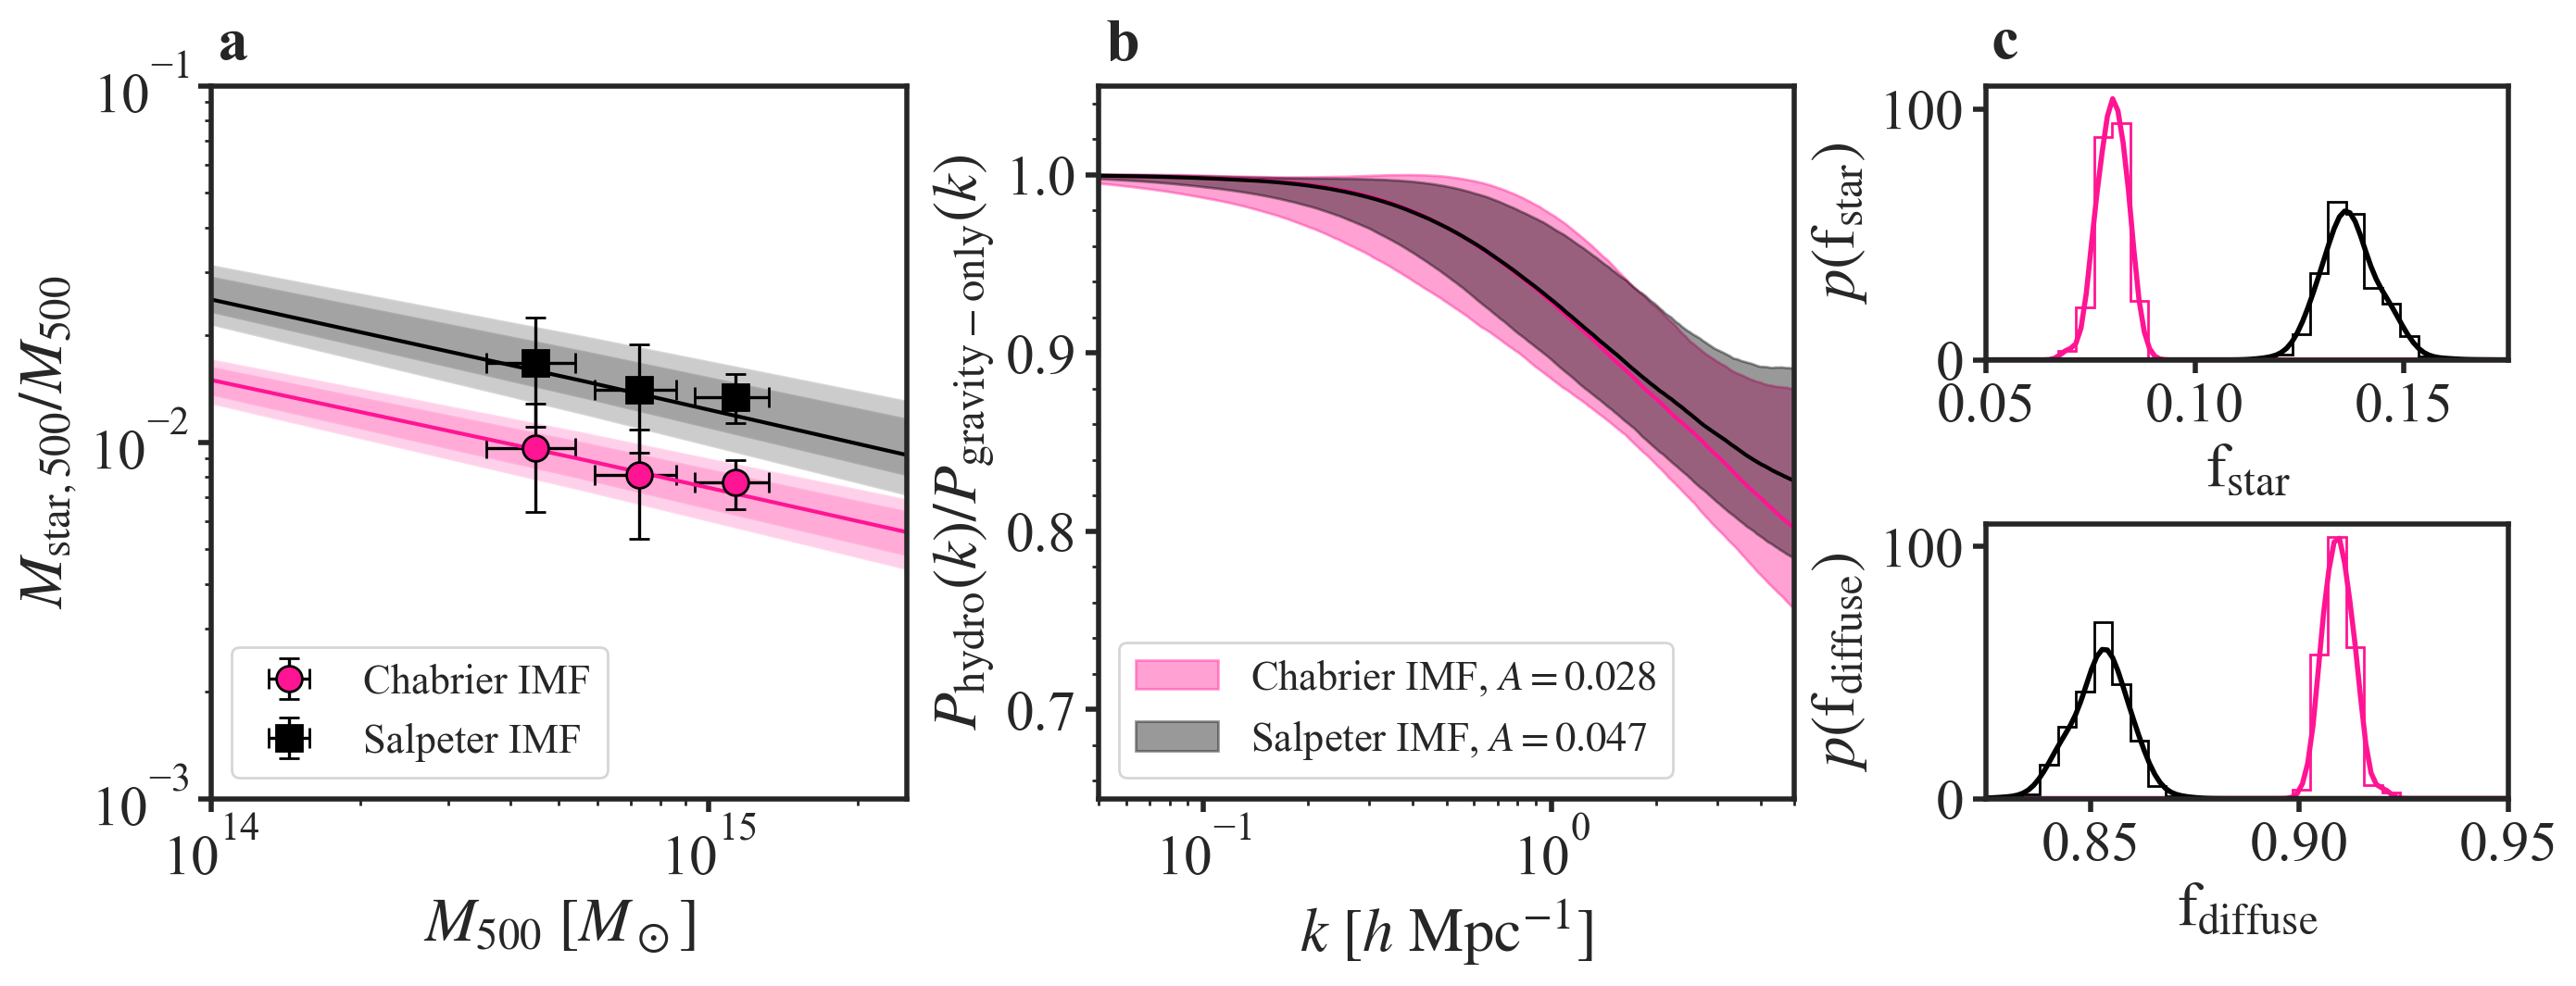

In [9]:
from joblib import Parallel, delayed
from scipy.stats import gaussian_kde

def f_star_eta(Mass, A, eta):
    par = dict(theta_ej = 3.5, theta_co = 0.1, M_c = (10**14)/cosmo_ccl.cosmo.params.h, 
               mu_beta = 1, eta = eta, eta_delta = 0.2, tau = -1.5, tau_delta = 0, A = A, 
               M1 = 2.5e11/cosmo_ccl.cosmo.params.h, epsilon_h = 0.015, a = 0.3, n = 2, 
               epsilon = 4, p = 0.3, q = 0.707, gamma = 2.5, delta = 9)
    mdef  = ccl.halos.massdef.MassDef500c
    CGA = bfg.Profiles.Schneider19.Stars(**par, mass_def = mdef, c_M_relation=ccl.halos.concentration.ConcentrationIshiyama21)
    SGA = bfg.Profiles.Schneider19.SatelliteStars(**par, mass_def = mdef, c_M_relation=ccl.halos.concentration.ConcentrationIshiyama21)
    R500c = mdef.get_radius(cosmo_ccl, Mass, 1) / 1
    out   = np.zeros_like(Mass) + -99
    for i in range(Mass.size):
        r = np.geomspace(R500c[i] * 1e-3, R500c[i] * 1, 1000)
        m_cga = np.trapz(4 * np.pi * r**2 * CGA.real(cosmo_ccl, r, Mass[i], 1), x = r)
        m_sga = np.trapz(4 * np.pi * r**2 * SGA.real(cosmo_ccl, r, Mass[i], 1), x = r)
        out[i] = (m_cga+m_sga)/Mass[i] 
    return out

M = 10**np.linspace(14, 15.5, 3)
def run_one(idx):
    return f_star_eta(M, A = As[idx], eta=etas[idx])

def sample_fstars(etas, As, n_jobs=1):
    results = Parallel(
        n_jobs=n_jobs,
        prefer="threads"   # <-- THIS FIXES THE PICKLING ERROR
    )(
        delayed(f_star_eta)(M, A = As[idx], eta=etas[idx]) for idx in range(len((etas)))
    )
    return np.array(results)

def plot_envelope(ax, fstars, color, alpha=0.2, label=None, edgecolor=None, hatch=None):
    """Plot median + 68% and 90% envelopes."""
    p = np.percentile
    ax.plot(M, p(fstars, 50, axis=0), color=color)
    ax.fill_between(M, p(fstars, 16, axis=0), p(fstars, 84, axis=0),
                    alpha=alpha, facecolor=color, edgecolor=edgecolor, hatch=hatch)
    ax.fill_between(M, p(fstars, 5, axis=0),  p(fstars, 95, axis=0),
                    alpha=alpha, facecolor=color, edgecolor=edgecolor, hatch=hatch)
    
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 5))

gs = gridspec.GridSpec(
    nrows=2, ncols=3,
    width_ratios=[1, 1.0, 0.75],  # tweak as needed
    wspace=0.3, hspace=0.6
)

ax1 = fig.add_subplot(gs[:, 0])   # left panel (spans both rows)
ax2 = fig.add_subplot(gs[:, 1])   # middle panel (spans both rows)
ax3 = fig.add_subplot(gs[0, 2])   # top-right panel
ax4 = fig.add_subplot(gs[1, 2])   # bottom-right panel


# ------------------------------------------------------------
# ---------------------- LEFT PANEL --------------------------
#      Stellar mass fraction vs. M500 (f_* envelope)
# ------------------------------------------------------------

# --- Data points -------------------------------------------------------------
ax1.errorbar(
    binned_spt_clusters["mean_M500"], binned_spt_clusters["mean_Mstar_M500"],
    xerr=binned_spt_clusters["err_M500"],
    yerr=binned_spt_clusters["err_Mstar_M500"],
    fmt='o', markersize=10, capsize=4,
    color='deeppink', markeredgecolor='black', ecolor='black',
    elinewidth=1.2, label="Chabrier IMF"
)


ax1.errorbar(
    binned_spt_clusters["mean_M500"], binned_spt_clusters["mean_Mstar_M500"]*(10**offset_Chabrier_to_Salpeter),
    xerr=binned_spt_clusters["err_M500"],
    yerr=binned_spt_clusters["err_Mstar_M500"]*(10**offset_Chabrier_to_Salpeter),
    fmt='s', markersize=10, capsize=4,
    color='black', markeredgecolor='black', ecolor='black',
    elinewidth=1.2, label="Salpeter IMF"
)


# # --- Posterior envelopes ----------------------------------------------------
plot_envelope(ax1, 
    sample_fstars(As = [0.055/2 for i in range(150)], etas = BCEmu6_samples_spt_ChabrierIMF[1000:1150, 4]), 
    color="deeppink", label=r"$\eta =0.22_{-0.05}^{+0.06}$"
)

plot_envelope(ax1,
    sample_fstars(As = BCEmu6_samples_spt_SalpeterIMF[1000:1150, 5], etas = BCEmu6_samples_spt_SalpeterIMF[1000:1150, 4]), 
    color="black", label=r"Salpeter IMF: $\eta = 0.18_{-0.05}^{+0.09}$"
)

# plot_envelope(ax1,
#     sample_fstars(samples_spt_KroupaIMF[1000:2000]), 
#     color="yellow", label=r"Kroupa IMF: $\eta = 0.22_{-0.05}^{+0.07}$",
# )

# --- Axes & formatting -------------------------------------------------------
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlim(10**14, 10**15.4)
ax1.set_ylim(1e-3, 0.1)
ax1.set_xlabel(r"$M_{500}~[M_\odot]$")
ax1.set_ylabel(r"$M_{\mathrm{star}, 500} / M_{500}$")
ax1.legend(loc="lower left", fontsize=16)


# ------------------------------------------------------------
# --------------------- RIGHT PANEL --------------------------
#     Ratio P_baryons(k) / P_gravity(k) (two priors)
# ------------------------------------------------------------

k_fields = np.geomspace(1e-4, 1e2, 1000)

variations = {
    "IMF": ["Salpeter"],
}

labels = {
    "IMF": [
        "Salpeter IMF, $A=0.047$",
        "Kroupa IMF",
    ],
}


hatch_styles = ["X", "O"]

ratio_spk_lo, ratio_spk_med, ratio_spk_hi = np.load('data/frb_results/shm_relation/spk_BCEmu6_extended_SPTprior_KroupaIMF_perturbAonly.npy')
ax2.plot(k_fields/(cosmo.H0.value/100), ratio_spk_med, color='deeppink')
ax2.fill_between(k_fields/(cosmo.H0.value/100), ratio_spk_lo, ratio_spk_hi, color='deeppink', alpha=0.4, label=r"Chabrier IMF, $A=0.028$")

ax2.set(
    xscale="log",
    xlabel=r"$k~[h~\mathrm{Mpc}^{-1}]$",
    xlim=(5e-2, 5),
    ylim=(0.65, 1.05),
)

for i, var in enumerate(variations["IMF"]):
    ratio_lo, ratio_med, ratio_hi = np.load(
        f"data/frb_results/shm_relation/spk_BCEmu6_extended_SPTprior_{var}IMF_perturbAonly.npy"
    )
    ax2.plot(
        k_fields/(cosmo.H0.value/100),
        ratio_med,
        color='black'
    )
    ax2.fill_between(
        k_fields/(cosmo.H0.value/100),
        ratio_lo,
        ratio_hi,
        color='black', 
#         edgecolor='black',
        alpha=0.4,
#         hatch=hatch_styles[i],
        label=labels["IMF"][i],
    )

ax2.set_ylabel(r"$P_\mathrm{hydro}(k)/P_\mathrm{gravity-only}(k)$")

ax2.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax2.yaxis.set_minor_locator(plt.MultipleLocator(0.02))

ax2.legend(loc="lower left", fontsize=16)  

fs_bins = np.linspace(0.05, 0.175, 30)
xx = np.linspace(0.05, 0.175, 100)

_ = ax3.hist(fs_samples_vary_A_eta_BCEmu6_spt_ChabrierIMF, bins=fs_bins, color="deeppink", histtype="step", density=True)
kde = gaussian_kde(fs_samples_vary_A_eta_BCEmu6_spt_ChabrierIMF, bw_method=0.45); yy = kde(xx)
ax3.plot(xx, yy, color="deeppink", lw=2)
                        
_ = ax3.hist(fs_samples_vary_A_eta_BCEmu6_spt_SalpeterIMF, bins=fs_bins, color="black", histtype="step", density=True)
kde = gaussian_kde(fs_samples_vary_A_eta_BCEmu6_spt_SalpeterIMF, bw_method=0.45); yy = kde(xx)
ax3.plot(xx, yy, color="black", lw=2)

ax3.set_xlim(0.05, 0.175)
ax3.set_xlabel("f$_\mathrm{star}$")

ax3.set_ylabel("$p(\mathrm{f}_\mathrm{star})$")

fd_bins = np.linspace(0.825, 0.95, 30)
xx = np.linspace(0.825, 0.95, 100)

_ = ax4.hist(fd_samples_vary_A_eta_BCEmu6_spt_ChabrierIMF, bins=fd_bins, color="deeppink", histtype="step", density=True)
kde = gaussian_kde(fd_samples_vary_A_eta_BCEmu6_spt_ChabrierIMF, bw_method=0.45); yy = kde(xx)
ax4.plot(xx, yy, color="deeppink", lw=2)
                        
_ = ax4.hist(fd_samples_vary_A_eta_BCEmu6_spt_SalpeterIMF, bins=fd_bins, color="black", histtype="step", density=True)
kde = gaussian_kde(fd_samples_vary_A_eta_BCEmu6_spt_SalpeterIMF, bw_method=0.45); yy = kde(xx)
ax4.plot(xx, yy, color="black", lw=2)


ax4.set_xlim(0.825, 0.95)
ax4.set_xlabel("f$_\mathrm{diffuse}$")

ax4.set_ylabel("$p(\mathrm{f}_\mathrm{diffuse})$")

ax1.text(0.01, 1.055, "a", ha='left', va='center', weight='bold', 
             transform=ax1.transAxes)
ax2.text(0.01, 1.055, "b", ha='left', va='center', weight='bold', 
             transform=ax2.transAxes)
ax3.text(0.01, 1.15, "c", ha='left', va='center', weight='bold', 
             transform=ax3.transAxes)

plt.savefig('figures/impact_of_IMF_perturbAonly.pdf', dpi=400, bbox_inches='tight')



In [10]:
cosmo_ccl = ccl.Cosmology(Omega_c = cosmo.Om0-cosmo.Ob0, 
                      Omega_b = cosmo.Ob0, 
                      h = cosmo.H0.value/100, 
                      sigma8 = 0.8111, 
                      n_s = 0.9665, 
                      matter_power_spectrum='linear'
                     )
fb = cosmo_ccl.cosmo.params.Omega_b / cosmo_ccl.cosmo.params.Omega_m # Cosmic baryon fraction

# Compute the mass fraction given a profile class
def compute_mass_fraction(Profile, Mass, a = 1, Rfac = 1):
    mdef  = ccl.halos.massdef.MassDef200c
    R200c = mdef.get_radius(cosmo_ccl, Mass, a) / a
    out   = np.zeros_like(Mass) + -99
    # Loop over masses and compute mass fraction for each
    for i in range(Mass.size):        
        r = np.geomspace(R200c[i] * 1e-4, R200c[i] * Rfac, 1000)
        m = np.trapz(4 * np.pi * r**2 * Profile.real(cosmo_ccl, r, Mass[i], a), x = r)
        out[i] = m/Mass[i]
    return out

c_M_relation = ccl.halos.concentration.ConcentrationDuffy08

M200c = np.geomspace(1e12, 1e16, 100)


## One parameter variations

In [11]:
import matplotlib.cm as cm
from matplotlib.colors import Normalize


# =========================
# Parameter utilities
# =========================

def default_parameters(cosmo_ccl):
    return dict(
        theta_ej=3.5,
        theta_co=0.1,
        M_c=1e14 / cosmo_ccl.cosmo.params.h,
        mu_beta=1,
        eta=0.2,
        eta_delta=0.2,
        tau=-1.5,
        tau_delta=0,
        A=0.055 / 2,
        M1=2.5e11 / cosmo_ccl.cosmo.params.h,
        epsilon_h=0.015,
        a=0.3,
        n=2,
        epsilon=4,
        p=0.3,
        q=0.707,
        gamma=2.5,
        delta=7,
    )


# =========================
# Profile construction
# =========================

def build_profiles(par, c_M_relation):
    mass_def = ccl.halos.massdef.MassDef200c

    GAS = bfg.Profiles.Schneider19.Gas(
        **par,
        mass_def=mass_def,
        c_M_relation=c_M_relation,
    )

    STR = (
        bfg.Profiles.Schneider19.Stars(
            **par,
            mass_def=mass_def,
            c_M_relation=c_M_relation,
        )
        + bfg.Profiles.Schneider19.SatelliteStars(
            **par,
            mass_def=mass_def,
            c_M_relation=c_M_relation,
        )
    )

    DMO = bfg.Profiles.Schneider19.DarkMatter(
        **par, 
        mass_def = ccl.halos.massdef.MassDef200c, 
        c_M_relation=c_M_relation)
    
    CLM = bfg.Profiles.Schneider19.CollisionlessMatter(
        **par, 
        mass_def = ccl.halos.massdef.MassDef200c, 
        c_M_relation=c_M_relation)
    
    STR_central = bfg.Profiles.Schneider19.Stars(
        **par, 
        mass_def = ccl.halos.massdef.MassDef200c, 
        c_M_relation=c_M_relation)
    
    DMB = bfg.Profiles.Schneider19.DarkMatterBaryon(**par,
                                                    gas = GAS, 
                                                    stars = STR_central, 
                                                    collisionlessmatter = CLM, 
                                                    darkmatter = DMO)

    return GAS, STR, DMB


def compute_fractions_and_spk(
    par,
    GAS,
    STR,
    DMO,
    M200c,
    Rfac,
    cosmo,
    k_fields,
):
    fgas = (
        compute_mass_fraction(GAS, M200c, Rfac=Rfac)
        / compute_mass_fraction(DMO, M200c, Rfac=Rfac)
    )

    fstr = (
        compute_mass_fraction(STR, M200c, Rfac=Rfac)
        / compute_mass_fraction(DMO, M200c, Rfac=Rfac)
    )

    SPk = SPk_BCEmu(
        cosmo.H0.value * 1e5 / Mpc,
        cosmo.Ob0,
        cosmo.Om0,
        0.8111,
        {
            "log_Mc": np.log10(par["M_c"]*(cosmo.H0.value/100)),
            "theta_ej": par["theta_ej"],
            "eta_delta": par["eta_delta"],
            "delta": par["delta"],
            "mu_beta": par["mu_beta"],
            "gamma": par["gamma"],
            "eta": par["eta"],
            "A": par["A"],
            "tau": par["tau"],
        },
    )

    return fstr, fgas, SPk



100%|█████████████████████████████████████████████████████████████████| 10/10 [05:23<00:00, 32.31s/it]


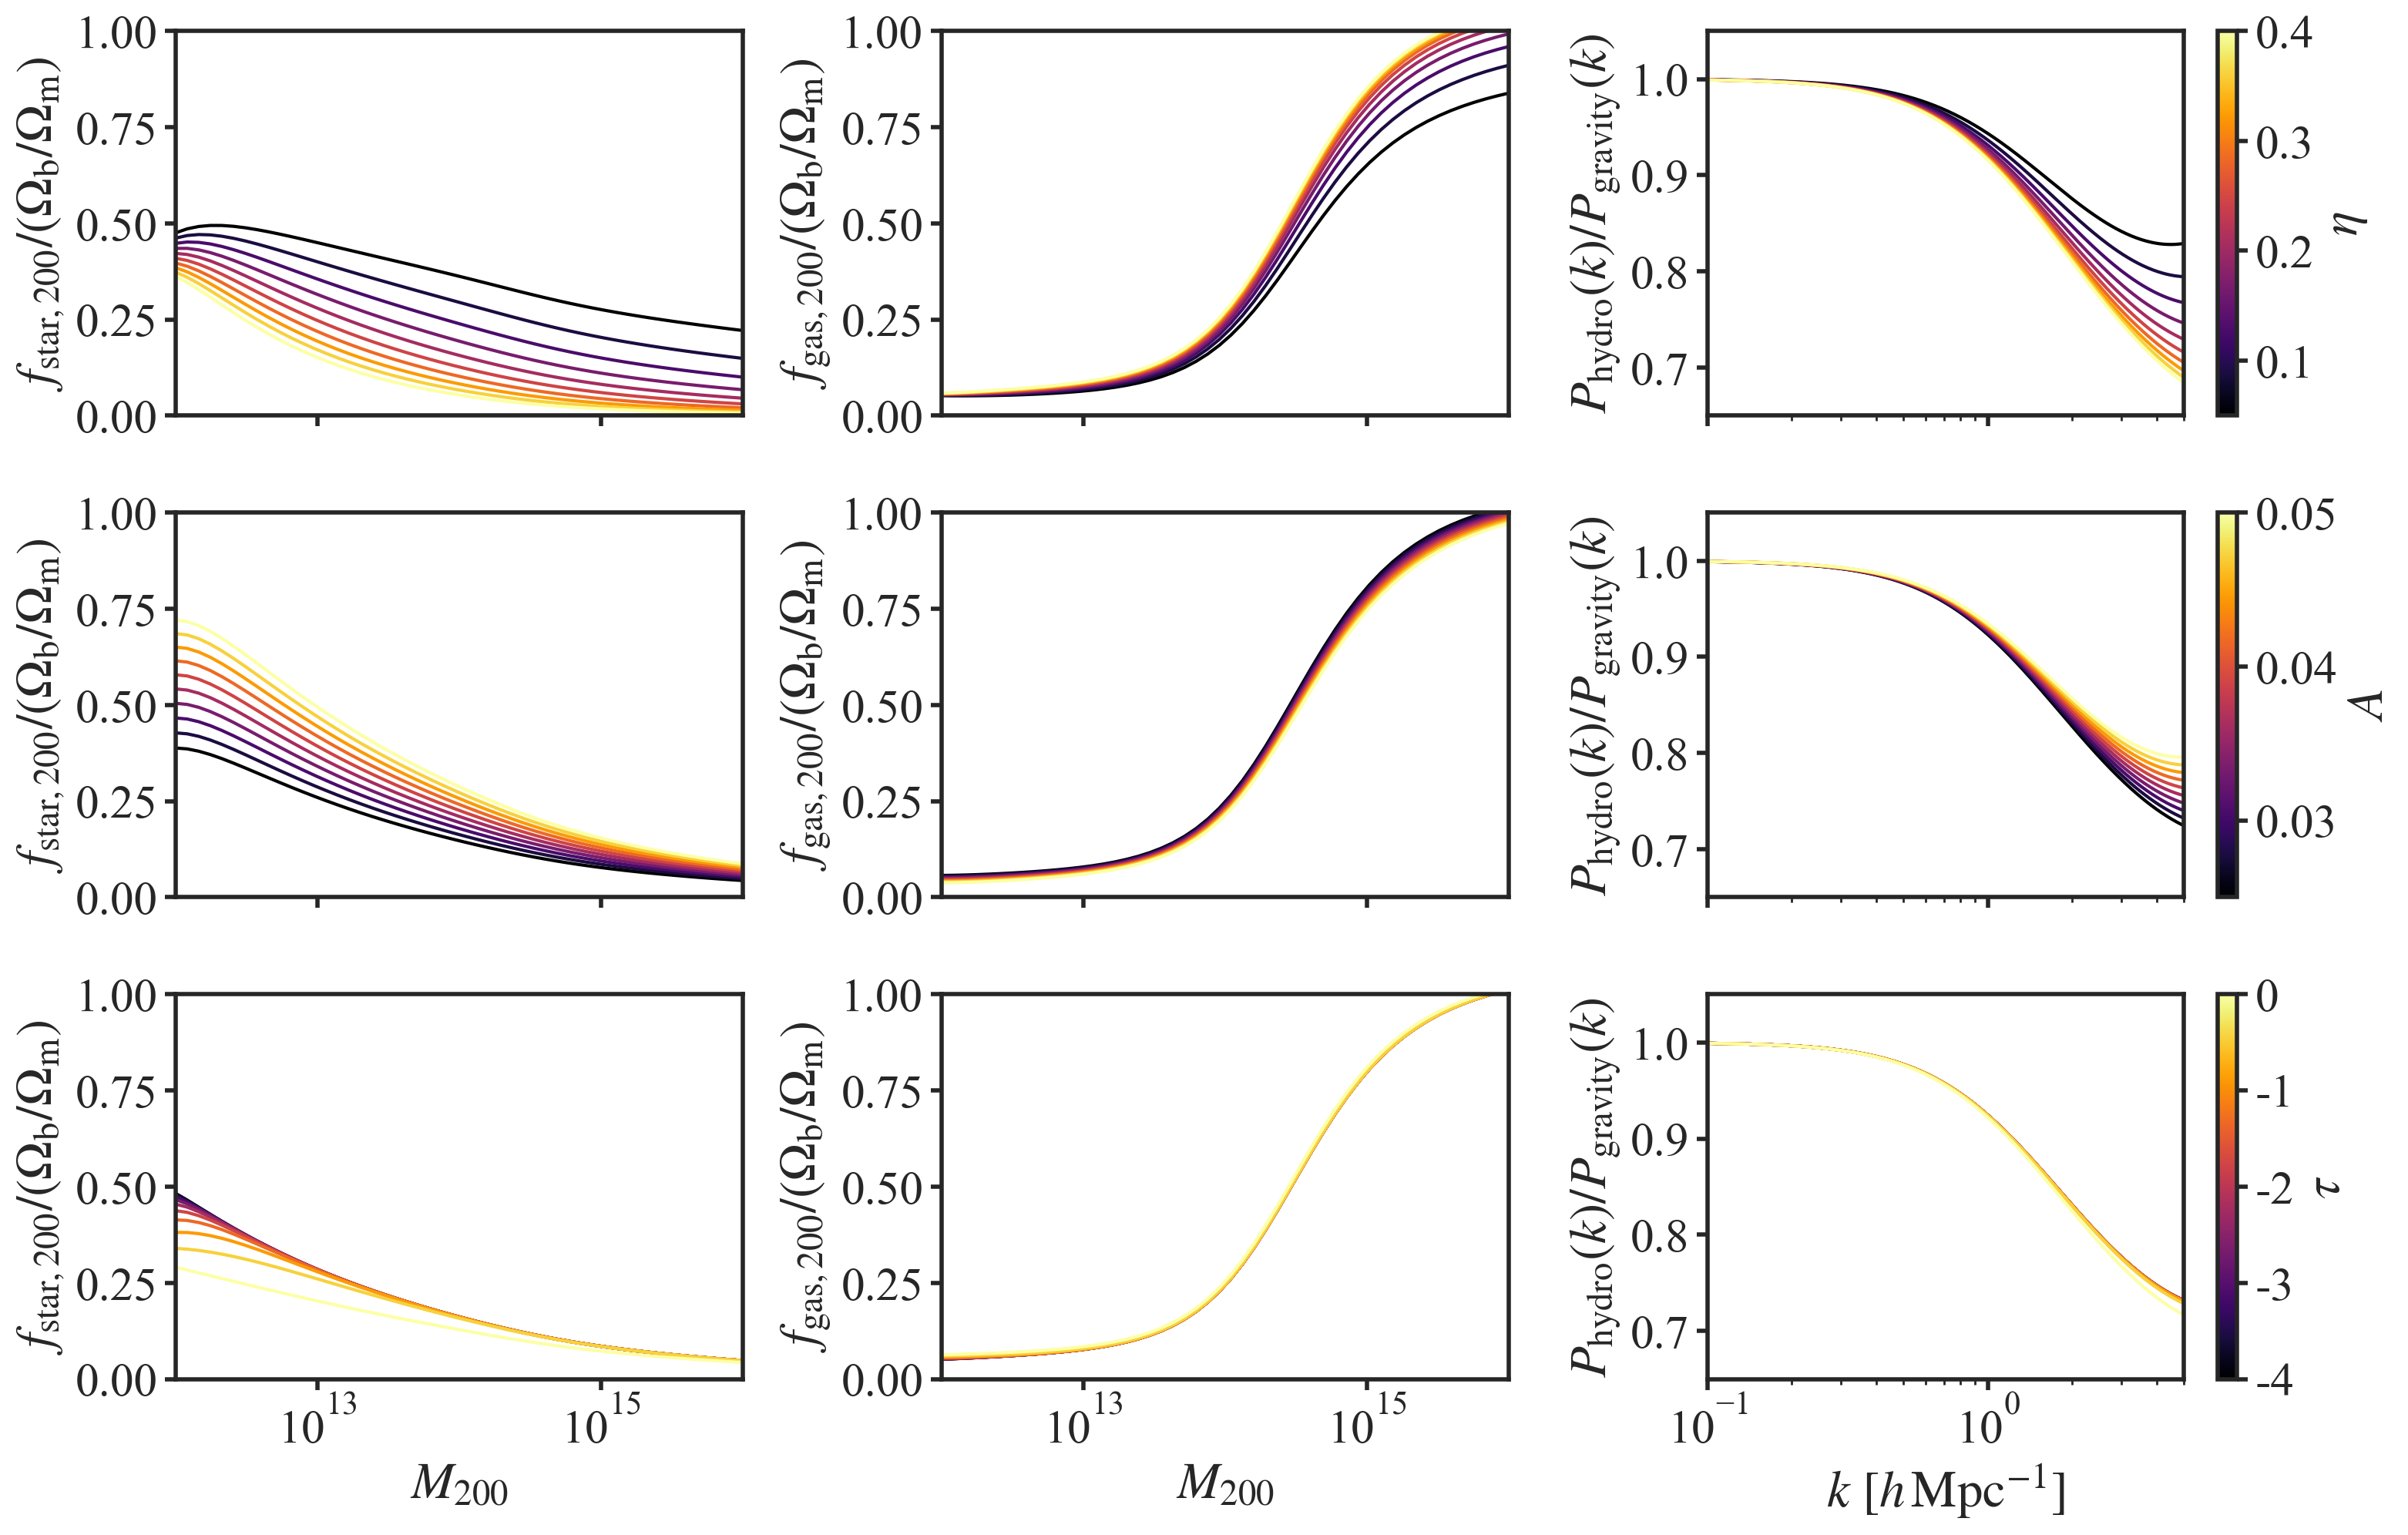

In [12]:
# =========================
# Plotting helper
# =========================

def plot_row(
    axes,
    param_values,
    param_name,
    par_template,
    Rfac,
    M200c,
    k_fields,
    cosmo,
    cosmo_ccl,
    c_M_relation,
    cmap,
    norm,
):
    ax_str, ax_gas, ax_pk = axes

    for i in tqdm(range(len(param_values))):
        val = param_values[i]
        par = par_template.copy()
        par[param_name] = val

        GAS, STR, DMO = build_profiles(par, c_M_relation)

        fstr, fgas, SPk = compute_fractions_and_spk(
            par,
            GAS,
            STR,
            DMO,
            M200c,
            Rfac,
            cosmo,
            k_fields,
        )

        color = cmap(norm(val))
        ax_str.plot(M200c, fstr/fb, color=color)
        ax_gas.plot(M200c, fgas/fb, color=color)
        ax_pk.plot(k_fields / (cosmo.H0.value / 100), SPk, color=color)
        
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    fig.colorbar(
        sm,
        ax=ax_pk,
        fraction=0.1,
        pad=0.06,
        label=cbar_labels[param_name],
    )

    
# =========================
# Main execution
# =========================

M200c = 10 ** np.linspace(12, 16, 50)

fig, axes = plt.subplots(
    3, 3,
    figsize=(16, 3.5*3),
    sharex="col",
)

cmap = cm.inferno
par0 = default_parameters(cosmo_ccl)
cbar_labels = {
    "eta": "$\eta$",
    "A": "$A$",
    "M_c": "M_c",
    "theta_ej": r"$\theta_\mathrm{ej}$",
    "mu_beta": r"$\mu_\beta$",
    "delta": r"$\delta$",
    "tau": r"$\tau$"
}


# ---- Row 1: vary eta ----
etas = np.linspace(0.05, 0.4, 10)
norm_eta = Normalize(vmin=etas.min(), vmax=etas.max())

plot_row(
    axes[0],
    etas,
    "eta",
    par0,
    Rfac=1,
    M200c=M200c,
    k_fields=k_fields,
    cosmo=cosmo,
    cosmo_ccl=cosmo_ccl,
    c_M_relation=c_M_relation,
    cmap=cmap,
    norm=norm_eta,
)


# ---- Row 2: vary A ----
As = np.linspace(0.025, 0.05, 10)
norm_A = Normalize(vmin=As.min(), vmax=As.max())

plot_row(
    axes[1],
    As,
    "A",
    par0,
    Rfac=1,
    M200c=M200c,
    k_fields=k_fields,
    cosmo=cosmo,
    cosmo_ccl=cosmo_ccl,
    c_M_relation=c_M_relation,
    cmap=cmap,
    norm=norm_A,
)


# ---- Row 3: vary tau ----
taus = np.linspace(-4, 0, 10)
norm_tau = Normalize(vmin=taus.min(), vmax=taus.max())

plot_row(
    axes[2],
    taus,
    "tau",
    par0,
    Rfac=1,
    M200c=M200c,
    k_fields=k_fields,
    cosmo=cosmo,
    cosmo_ccl=cosmo_ccl,
    c_M_relation=c_M_relation,
    cmap=cmap,
    norm=norm_tau,
)

for row in axes:
    row[0].set_xscale("log")
    row[1].set_xscale("log")
    row[2].set_xscale("log")

    row[0].set_ylabel(r"$f_\mathrm{star, 200}/(\Omega_\mathrm{b}/\Omega_\mathrm{m})$")
    row[0].set_ylim(0, 1)
    row[0].set_xlim(1e12, 1e16)
    row[1].set_ylabel(r"$f_\mathrm{gas, 200}/(\Omega_\mathrm{b}/\Omega_\mathrm{m})$")
    row[1].set_ylim(0, 1)
    row[1].set_xlim(1e12, 1e16)
    row[2].set_ylabel(r"$P_\mathrm{hydro}(k)/P_\mathrm{gravity}(k)$")
    row[2].set_ylim(0.65, 1.05)
    row[2].set_xlim(0.1, 5)
    

axes[2, 0].set_xlabel(r"$M_\mathrm{200}$")
axes[2, 1].set_xlabel(r"$M_\mathrm{200}$")
axes[2, 2].set_xlabel(r"$k$ $[h\,\mathrm{Mpc}^{-1}]$")

plt.tight_layout()
plt.savefig('figures/parameter_variations-f_gasR200M_f_starR200M_SPk.pdf', dpi=400, bbox_inches='tight')



In [ ]:
from matplotlib.colors import LogNorm
# =========================
# Radial observables
# =========================

def compute_radial_fractions(GAS, STR, DMO, M200c, r_fracs):
    fgas, fstr = [], []

    for r in r_fracs:
        fgas.append(
            compute_mass_fraction(GAS, M200c, Rfac=r)
            / compute_mass_fraction(DMO, M200c, Rfac=r)
        )
        fstr.append(
            compute_mass_fraction(STR, M200c, Rfac=r)
            / compute_mass_fraction(DMO, M200c, Rfac=r)
        )

    return np.array(fgas), np.array(fstr)


# =========================
# Row plotting helper
# =========================

def plot_row_radial(
    fig,
    axes,
    param_values,
    param_name,
    par_template,
    r_fracs,
    k_fields,
    cosmo,
    cosmo_ccl,
    c_M_relation,
    cmap,
    norm,
    cbar_label,
):
    ax_gas, ax_str, ax_bar, ax_pk = axes

    for i in tqdm(range(len(param_values))):
        val = param_values[i]
        par = par_template.copy()
        par[param_name] = val

        GAS, STR, DMO = build_profiles(par, c_M_relation)
        color = cmap(norm(val))

        # ---- M = 1e14 (solid) ----
        fgas, fstr = compute_radial_fractions(
            GAS, STR, DMO, np.array([1e14]), r_fracs
        )

        ax_gas.plot(r_fracs, fgas/fb, color=color)
        ax_str.plot(r_fracs, fstr/fb, color=color)
        ax_bar.plot(r_fracs, (fgas + fstr)/fb, color=color)

        # ---- M = 1e13 (dashed) ----
        fgas, fstr = compute_radial_fractions(
            GAS, STR, DMO, np.array([1e13]), r_fracs
        )

        ax_gas.plot(r_fracs, fgas/fb, color=color, ls="--")
        ax_str.plot(r_fracs, fstr/fb, color=color, ls="--")
        ax_bar.plot(r_fracs, (fgas + fstr)/fb, color=color, ls="--")

        # ---- SP(k) ----
        SPk = SPk_BCEmu(
            cosmo.H0.value * 1e5 / Mpc,
            cosmo.Ob0,
            cosmo.Om0,
            0.8111,
            {
                "log_Mc": np.log10(par["M_c"]*(cosmo.H0.value/100)),
                "theta_ej": par["theta_ej"],
                "eta_delta": par["eta_delta"],
                "delta": par["delta"],
                "mu_beta": par["mu_beta"],
                "gamma": par["gamma"],
                "eta": par["eta"],
                "A": par["A"],
                "tau": par["tau"],
            },
        )

        ax_pk.plot(
            k_fields / (cosmo.H0.value / 100),
            SPk,
            color=color,
        )

    # ---- Colorbar ----
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    fig.colorbar(
        sm,
        ax=ax_pk,
        fraction=0.08,
        pad=0.05,
        label=cbar_label,
    )


# =========================
# Main execution
# =========================

r_fracs = 10**np.linspace(-1, 1, 20)
cmap = cm.inferno
par0 = default_parameters(cosmo_ccl)

fig, axes = plt.subplots(
    6, 4,
    figsize=(16, 3*6),
    sharex="col",
)

# ---- Row 1: vary eta ----
etas = np.linspace(0.05, 0.4, 10)
norm_eta = Normalize(vmin=etas.min(), vmax=etas.max())

plot_row_radial(
    fig,
    axes[0],
    etas,
    "eta",
    par0,
    r_fracs,
    k_fields,
    cosmo,
    cosmo_ccl,
    c_M_relation,
    cmap,
    norm_eta,
    r"$\eta$",
)

# ---- Row 2: vary A ----
As = np.linspace(0.025, 0.05, 10)
norm_A = Normalize(vmin=As.min(), vmax=As.max())

plot_row_radial(
    fig,
    axes[1],
    As,
    "A",
    par0,
    r_fracs,
    k_fields,
    cosmo,
    cosmo_ccl,
    c_M_relation,
    cmap,
    norm_A,
    r"$A$",
)

# ---- Row 3: vary log_Mc ----
Mcs = (10**np.linspace(12, 15, 10))/(cosmo.H0.value/100)
norm_Mc = LogNorm(vmin=Mcs.min(), vmax=Mcs.max())

plot_row_radial(
    fig,
    axes[2],
    Mcs,
    "M_c",
    par0,
    r_fracs,
    k_fields,
    cosmo,
    cosmo_ccl,
    c_M_relation,
    cmap,
    norm_Mc,
    r"$M_c$",
)

# ---- Row 4: vary theta_ej ----
theta_ejs = np.linspace(2, 8, 10)
norm_theta_ej = Normalize(vmin=theta_ejs.min(), vmax=theta_ejs.max())

plot_row_radial(
    fig,
    axes[3],
    theta_ejs,
    "theta_ej",
    par0,
    r_fracs,
    k_fields,
    cosmo,
    cosmo_ccl,
    c_M_relation,
    cmap,
    norm_theta_ej,
    r"$\theta_\mathrm{ej}$",
)

# ---- Row 5: vary mu_beta ----
mu_betas = np.linspace(0, 2, 10)
norm_mu_beta = Normalize(vmin=mu_betas.min(), vmax=mu_betas.max())

plot_row_radial(
    fig,
    axes[4],
    mu_betas,
    "mu_beta",
    par0,
    r_fracs,
    k_fields,
    cosmo,
    cosmo_ccl,
    c_M_relation,
    cmap,
    norm_mu_beta,
    r"$\mu_\beta$",
)

# ---- Row 6: vary delta ----
deltas = np.linspace(3, 11, 10)
norm_delta = Normalize(vmin=deltas.min(), vmax=deltas.max())

plot_row_radial(
    fig,
    axes[5],
    deltas,
    "delta",
    par0,
    r_fracs,
    k_fields,
    cosmo,
    cosmo_ccl,
    c_M_relation,
    cmap,
    norm_delta,
    r"$\delta$",
)


for row in axes:
    row[0].set_ylabel(r"$f_\mathrm{gas}(R)/(\Omega_\mathrm{b}/\Omega_\mathrm{m})$")
    row[1].set_ylabel(r"$f_\mathrm{star}(R)/(\Omega_\mathrm{b}/\Omega_\mathrm{m})$")
    row[2].set_ylabel(r"$f_\mathrm{baryons}(R)/(\Omega_\mathrm{b}/\Omega_\mathrm{m})$")
    row[3].set_ylabel(r"$P_\mathrm{hydro}(k)/P_\mathrm{gravity}(k)$")

    row[0].set_ylim(0, 1)
    row[1].set_ylim(0, 1)
    row[2].set_ylim(0, 1)

    
    row[0].set_xscale("log")
    row[0].set_xlim(0.1, 10)
    row[1].set_xscale("log")
    row[1].set_xlim(0.1, 10)
    row[2].set_xscale("log")
    row[2].set_xlim(0.1, 10)
    row[3].set_xscale("log")
    row[3].set_xlim(0.1, 5)
    row[3].set_ylim(0.65, 1.05)

axes[5, 0].set_xlabel(r"$R/R_\mathrm{200c}$")
axes[5, 1].set_xlabel(r"$R/R_\mathrm{200c}$")
axes[5, 2].set_xlabel(r"$R/R_\mathrm{200c}$")
axes[5, 3].set_xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")

plt.tight_layout()
plt.savefig('figures/parameter_variations-f_gasR_f_starR_f_baryonsR_SPk.pdf', dpi=400, bbox_inches='tight')



 20%|█████████████▏                                                    | 2/10 [00:52<03:30, 26.34s/it]